## 1️⃣ Setup & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid", palette="muted")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

data_dir = ROOT / "data"

# Load cleaned data from the project root data folder.
reliance = pd.read_csv(data_dir / "cleaned" / "reliance_clean.csv", index_col="Date", parse_dates=True)
tcs      = pd.read_csv(data_dir / "cleaned" / "tcs_clean.csv",      index_col="Date", parse_dates=True)
infosys  = pd.read_csv(data_dir / "cleaned" / "infosys_clean.csv",  index_col="Date", parse_dates=True)
hdfc     = pd.read_csv(data_dir / "cleaned" / "hdfcbank_clean.csv", index_col="Date", parse_dates=True)

print("Clean data loaded successfully!")

Clean data loaded successfully!


### Data Loading for Feature Engineering

- In this step, the cleaned datasets for Reliance, TCS, Infosys, and HDFC Bank are loaded from the `data/cleaned` folder.
- The `Date` column is used as the index and parsed as a datetime object, which is important for time-series analysis.
- Since the data is already cleaned, it is ready for feature engineering and model preparation.
- This step ensures that all four stock datasets are in a consistent format before creating new features such as returns, moving averages, volatility, and lag values.


## 2️⃣ Generate Base Technical Features

In [2]:
# Lags, Returns, Moving Averages
lags = [1, 7, 14, 30]
ma_windows = [7, 14, 21, 50, 100]
ema_windows = [7, 14, 21, 50]

for df in [reliance, tcs, infosys, hdfc]:
    # Daily Returns
    df["Daily_Return"] = df["Close"].pct_change() * 100
    
    # Lags
    for lag in lags:
        df[f"Lag_{lag}"] = df["Close"].shift(lag)
        
    # Moving Averages (SMA)
    for w in ma_windows:
        df[f"MA_{w}"] = df["Close"].rolling(w).mean()
        
    # Exponential Moving Averages (EMA)
    for w in ema_windows:
        df[f"EMA_{w}"] = df["Close"].ewm(span=w, adjust=False).mean()

print("Base features (Returns, Lags, MAs, EMAs) generated!")

Base features (Returns, Lags, MAs, EMAs) generated!


### Base Feature Engineering

- In this step, we create a set of basic time-series features for all four stocks: Reliance, TCS, Infosys, and HDFC Bank.
- `Daily_Return` captures the percentage change in closing price from one day to the next, which helps measure short-term movement.
- Lag features (`Lag_1`, `Lag_7`, `Lag_14`, `Lag_30`) store past closing prices and help the model learn from previous trends.
- Simple Moving Averages (`MA_7`, `MA_14`, `MA_21`, `MA_50`, `MA_100`) smooth out short-term fluctuations and show the broader price trend.
- Exponential Moving Averages (`EMA_7`, `EMA_14`, `EMA_21`, `EMA_50`) give more weight to recent prices, making them more responsive to recent market changes.
- These engineered features are useful for capturing momentum, trend direction, and historical dependence in stock prices.


## 3️⃣ Advanced Technical Indicators (RSI, MACD, Volatility)

In [3]:
def compute_rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, min_periods=fast).mean()
    ema_slow = prices.ewm(span=slow, min_periods=slow).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, min_periods=signal).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

vol_windows = [7, 14, 21]

for df in [reliance, tcs, infosys, hdfc]:
    df["RSI_14"] = compute_rsi(df["Close"], 14)
    df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(df["Close"])
    
    # Volatility (Standard Deviation of returns)
    for w in vol_windows:
        df[f"Volatility_{w}"] = df["Close"].pct_change().rolling(w).std()

# Note: Removed the "Direction" feature calculation here to prevent Target Data Leakage (Fix #2)
print("RSI, MACD, and Volatility added!")

RSI, MACD, and Volatility added!


### Technical Indicator Features

- This step adds technical indicators to capture stock momentum and volatility.
- `RSI_14` measures whether the stock is in an overbought or oversold condition over a 14-day window.
- `MACD`, `MACD_Signal`, and `MACD_Hist` help identify trend strength and possible trend reversals.
- `Volatility_7`, `Volatility_14`, and `Volatility_21` measure the variability of returns over different time windows.
- These features are useful because they add trend and momentum information beyond simple price values.
- The `Direction` feature was intentionally removed to avoid target leakage and keep the model evaluation realistic.


## 4️⃣ Advanced Oscillators (ATR, ROC, Bollinger, CCI, OBV)

In [4]:
def compute_atr(df, window=14):
    high_low = df["High"] - df["Low"]
    high_pc = (df["High"] - df["Close"].shift(1)).abs()
    low_pc  = (df["Low"]  - df["Close"].shift(1)).abs()
    true_range = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
    return true_range.rolling(window=window).mean()

def compute_roc(df, period=12):
    return ((df["Close"] - df["Close"].shift(period)) / df["Close"].shift(period)) * 100

def compute_williams_r(df, window=14):
    highest_high = df["High"].rolling(window).max()
    lowest_low   = df["Low"].rolling(window).min()
    return -100 * ((highest_high - df["Close"]) / (highest_high - lowest_low + 1e-10)) # Added 1e-10 for safety

# Vectorized OBV logic (Fix #3)
def compute_obv(df):
    direction = np.sign(df["Close"].diff())
    df["OBV"] = (direction * df["Volume"]).fillna(0).cumsum()
    return df

def compute_stochastic(df, window=14, smooth_k=3):
    low_min  = df["Low"].rolling(window).min()
    high_max = df["High"].rolling(window).max()
    df["Stoch_%K"] = 100 * ((df["Close"] - low_min) / (high_max - low_min + 1e-10))
    df["Stoch_%D"] = df["Stoch_%K"].rolling(smooth_k).mean()
    return df

def compute_cci(df, window=20):
    tp = (df["High"] + df["Low"] + df["Close"]) / 3
    tp_ma = tp.rolling(window).mean()
    mean_dev = tp.rolling(window).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw=True)
    df["CCI"] = (tp - tp_ma) / (0.015 * mean_dev + 1e-10)
    return df

roc_periods = [5, 10, 14, 21]
for df in [reliance, tcs, infosys, hdfc]:
    # Bollinger Bands
    df["MA20"] = df["Close"].rolling(window=20).mean()
    df["STD20"] = df["Close"].rolling(window=20).std()
    df["Upper_Band"] = df["MA20"] + (2 * df["STD20"])
    df["Lower_Band"] = df["MA20"] - (2 * df["STD20"])
    
    df["ATR_14"] = compute_atr(df, window=14)
    df["Williams_%R"] = compute_williams_r(df, 14)
    
    for p in roc_periods:
        df[f"ROC_{p}"] = compute_roc(df, period=p)
        
    compute_obv(df)
    compute_stochastic(df, 14, 3)
    compute_cci(df, 20)

print("Advanced oscillators & indicators generated!")

Advanced oscillators & indicators generated!


### Advanced Technical Indicators

- This step adds more technical indicators to capture volatility, momentum, and trend behavior.
- Bollinger Bands help us see price range and volatility around the moving average.
- ATR measures average price movement and market volatility.
- Williams %R shows overbought and oversold conditions.
- ROC measures how fast price changes over different periods.
- OBV combines price and volume to show buying/selling pressure.
- Stochastic indicators help identify momentum shifts and possible reversals.
- CCI helps detect when price is unusually high or low compared to its average.
- These features make the dataset richer and more useful for prediction.


## 5️⃣ Drop Initial NaNs
**Crucial Fix (#4):** We drop the rows containing missing values generated by rolling/shifting windows *only after ALL features have been engineered.*

In [5]:
for df in [reliance, tcs, infosys, hdfc]:
    df.dropna(inplace=True)
    
print("Dropped initial null rows created by shifting/rolling features.")
print("Feature count per dataset:", len(reliance.columns))

Dropped initial null rows created by shifting/rolling features.
Feature count per dataset: 40


### Missing Value Handling

- Rolling and lag-based features create missing values at the start of the dataset.
- These rows are removed using `dropna()` so that all remaining records have complete feature values.
- After this step, the dataset is ready for modeling.


## 6️⃣ Feature Visualization Preview

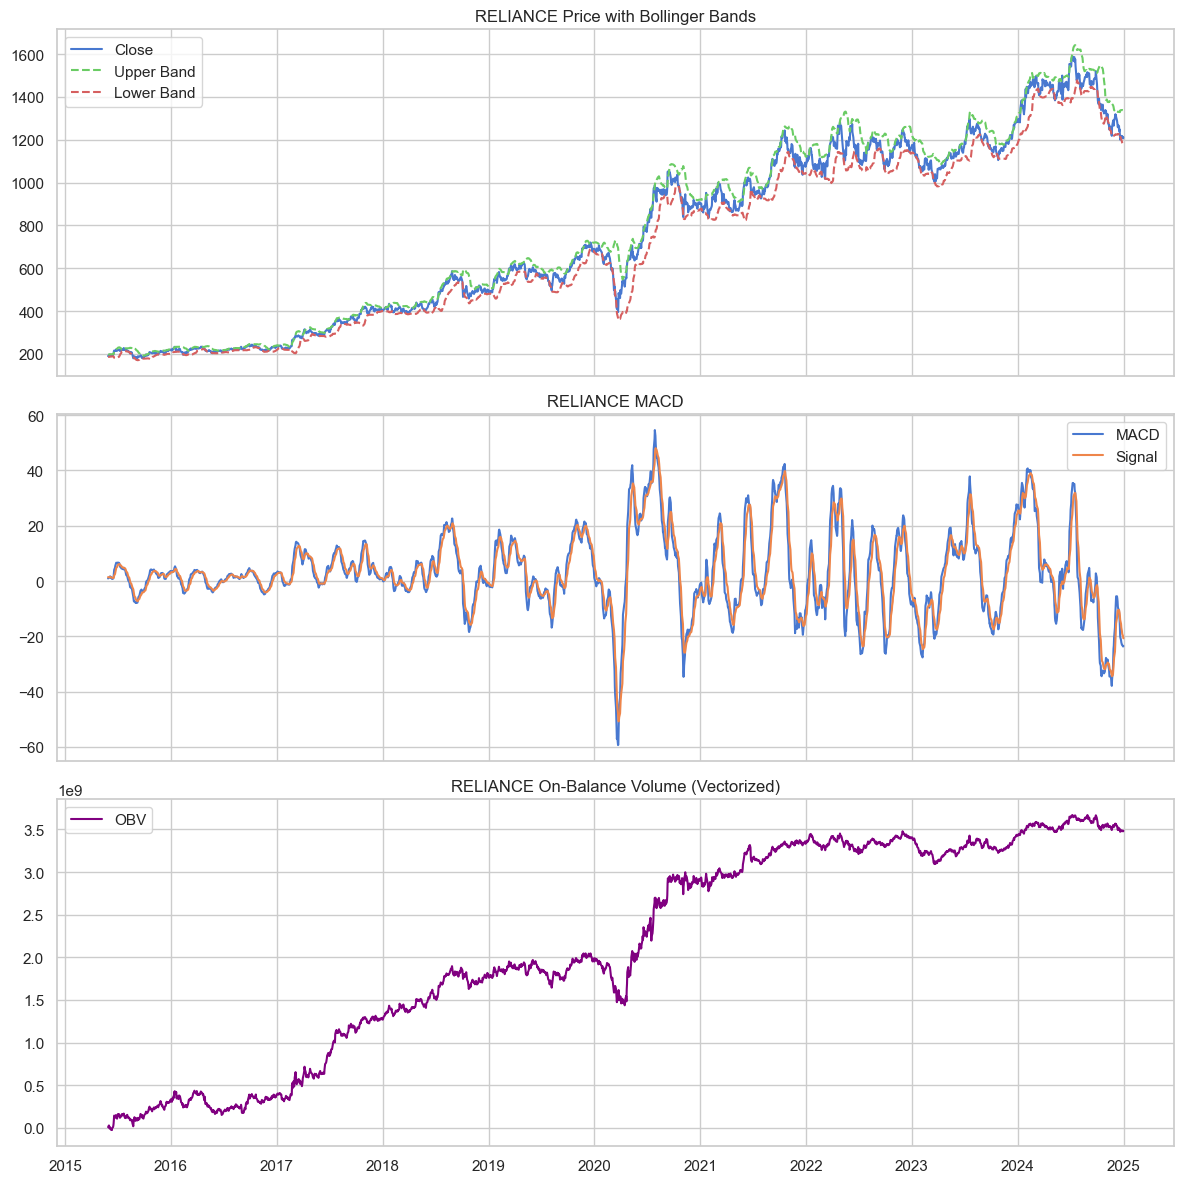

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Price + Bollinger
ax[0].plot(reliance["Close"], label="Close")
ax[0].plot(reliance["Upper_Band"], label="Upper Band", linestyle="--", color="g")
ax[0].plot(reliance["Lower_Band"], label="Lower Band", linestyle="--", color="r")
ax[0].set_title("RELIANCE Price with Bollinger Bands")
ax[0].legend()

# MACD
ax[1].plot(reliance["MACD"], label="MACD")
ax[1].plot(reliance["MACD_Signal"], label="Signal")
ax[1].set_title("RELIANCE MACD")
ax[1].legend()

# OBV
ax[2].plot(reliance["OBV"], label="OBV", color="purple")
ax[2].set_title("RELIANCE On-Balance Volume (Vectorized)")
ax[2].legend()

plt.tight_layout()
plt.show()

## 7️⃣ Save Engineered Features for Modeling
**Crucial Fix (#5):** Export datasets to `data/features/` so the model training module can simply load them.

In [7]:
(data_dir / "features").mkdir(parents=True, exist_ok=True)

reliance.to_csv(data_dir / "features" / "reliance_feat.csv")
tcs.to_csv(data_dir / "features" / "tcs_feat.csv")
infosys.to_csv(data_dir / "features" / "infosys_feat.csv")
hdfc.to_csv(data_dir / "features" / "hdfcbank_feat.csv")

print("Engineered feature datasets saved to the project-root data/features/ folder successfully!")

Engineered feature datasets saved to 'data/features/' successfully!


### Saving Final Feature Datasets

- After feature engineering is complete, the processed datasets are saved into the `data/features` folder.
- Each stock has its own final feature file:
  - `reliance_feat.csv`
  - `tcs_feat.csv`
  - `infosys_feat.csv`
  - `hdfcbank_feat.csv`
- This step makes the engineered data reusable for model training without having to recompute all features again.
- Saving the final datasets also helps keep the workflow organized and reproducible.
